# Model II Training - Maroua

Train and compare Random Forest, XGBoost, and LSTM on the realistic Model II feature set from `feature_model_II.ipynb`.
Solar radiation components (`ALLSKY_SFC_SW_DNI`, `ALLSKY_SFC_SW_DIFF`) are excluded to avoid data leakage.

In [1]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.models import Sequential
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
os.makedirs("saved_models/model_ii", exist_ok=True)


## Load Model II Feature Dataset

In [2]:
maroua = pd.read_csv("../Data/Processed/Maroua_Features_Model_II.csv")
print("Maroua shape:", maroua.shape)
maroua.head()

Maroua shape: (52584, 28)


,YEAR,MO,DY,HR,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,ALLSKY_SFC_SW_DIFF,T2M,RH2M,PRECTOTCORR,...,month_cos,day_sin,day_cos,is_daytime,is_rainy,rain_log1p,ws10m_log1p,season,season_dry,season_rainy
0,2020,1,1,0,0.0,0.0,0.0,19.53,22.81,0.0,...,0.866025,0.017213,0.999852,0,0,0.0,1.822935,dry,1,0
1,2020,1,1,1,0.0,0.0,0.0,18.66,24.00,0.0,...,0.866025,0.017213,0.999852,0,0,0.0,1.814825,dry,1,0
2,2020,1,1,2,0.0,0.0,0.0,17.88,25.20,0.0,...,0.866025,0.017213,0.999852,0,0,0.0,1.811562,dry,1,0
3,2020,1,1,3,0.0,0.0,0.0,17.17,26.52,0.0,...,0.866025,0.017213,0.999852,0,0,0.0,1.821318,dry,1,0
4,2020,1,1,4,0.0,0.0,0.0,16.50,27.93,0.0,...,0.866025,0.017213,0.999852,0,0,0.0,1.830980,dry,1,0


## Feature List

In [3]:
model_ii_features = [
    "YEAR",
    "MO",
    "DY",
    "HR",
    "T2M",
    "RH2M",
    "PRECTOTCORR",
    "WS10M",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos",
    "day_of_year",
    "is_daytime",
    "is_rainy",
    "rain_log1p",
    "ws10m_log1p",
    "season_dry",
    "season_rainy"
]

target = "ALLSKY_SFC_SW_DWN"


## Train / Test Split

In [4]:
X = maroua[model_ii_features]
y = maroua[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (42067, 21)
Testing shape: (10517, 21)


## Random Forest

In [5]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE =", mae_rf)
print("RMSE =", rmse_rf)
print("R2 =", r2_rf)

Random Forest
MAE = 26.530059503660745
RMSE = 61.108857344919265
R2 = 0.964618857035119


In [6]:
feature_importance = pd.DataFrame({
    "Feature": model_ii_features,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
9,hour_cos,0.905226
8,hour_sin,0.016478
3,HR,0.012221
6,PRECTOTCORR,0.010165
17,rain_log1p,0.009657
5,RH2M,0.009630
4,T2M,0.008836
14,day_of_year,0.005104
2,DY,0.003819
13,day_cos,0.003792


## XGBoost

In [7]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost")
print("MAE =", mae_xgb)
print("RMSE =", rmse_xgb)
print("R2 =", r2_xgb)

XGBoost
MAE = 26.545543499707705
RMSE = 60.19542571979261
R2 = 0.9656686791364483


## LSTM

In [8]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

def create_sequences(X_data, y_data, seq_length):
    Xs, ys = [], []
    for i in range(len(X_data) - seq_length):
        Xs.append(X_data[i:i + seq_length])
        ys.append(y_data[i + seq_length])
    return np.array(Xs), np.array(ys)

seq_length = 24
X_lstm, y_lstm = create_sequences(X_scaled, y_scaled, seq_length)

split_index = int(len(X_lstm) * 0.8)
X_train_lstm = X_lstm[:split_index]
X_test_lstm = X_lstm[split_index:]
y_train_lstm = y_lstm[:split_index]
y_test_lstm = y_lstm[split_index:]

In [9]:
lstm_model = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    LSTM(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,129 (94.25 KB)

 Trainable params: 24,129 (94.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.0093 - val_loss: 0.0045
Epoch 2/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0051 - val_loss: 0.0043
Epoch 3/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0046 - val_loss: 0.0056
Epoch 4/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0044 - val_loss: 0.0049
Epoch 5/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0042 - val_loss: 0.0050
Epoch 6/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0041 - val_loss: 0.0049
Epoch 7/20
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0041 - val_loss: 0.0074


In [11]:
y_pred_lstm = lstm_model.predict(X_test_lstm)
y_test_actual = scaler_y.inverse_transform(y_test_lstm)
y_pred_actual = scaler_y.inverse_transform(y_pred_lstm)

mae_lstm = mean_absolute_error(y_test_actual, y_pred_actual)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2_lstm = r2_score(y_test_actual, y_pred_actual)

print("LSTM")
print("MAE =", mae_lstm)
print("RMSE =", rmse_lstm)
print("R2 =", r2_lstm)

329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
LSTM
MAE = 42.40135664605076
RMSE = 74.16633763679934
R2 = 0.9500143215639808


## Model Comparison

In [12]:
results = pd.DataFrame({
    "City": "Maroua",
    "Model": ["Random Forest", "XGBoost", "LSTM"],
    "MAE": [mae_rf, mae_xgb, mae_lstm],
    "RMSE": [rmse_rf, rmse_xgb, rmse_lstm],
    "R2": [r2_rf, r2_xgb, r2_lstm]
})

results.to_csv("results_maroua_model_ii.csv", index=False)
results

,City,Model,MAE,RMSE,R2
0,Maroua,Random Forest,26.530060,61.108857,0.964619
1,Maroua,XGBoost,26.545543,60.195426,0.965669
2,Maroua,LSTM,42.401357,74.166338,0.950014


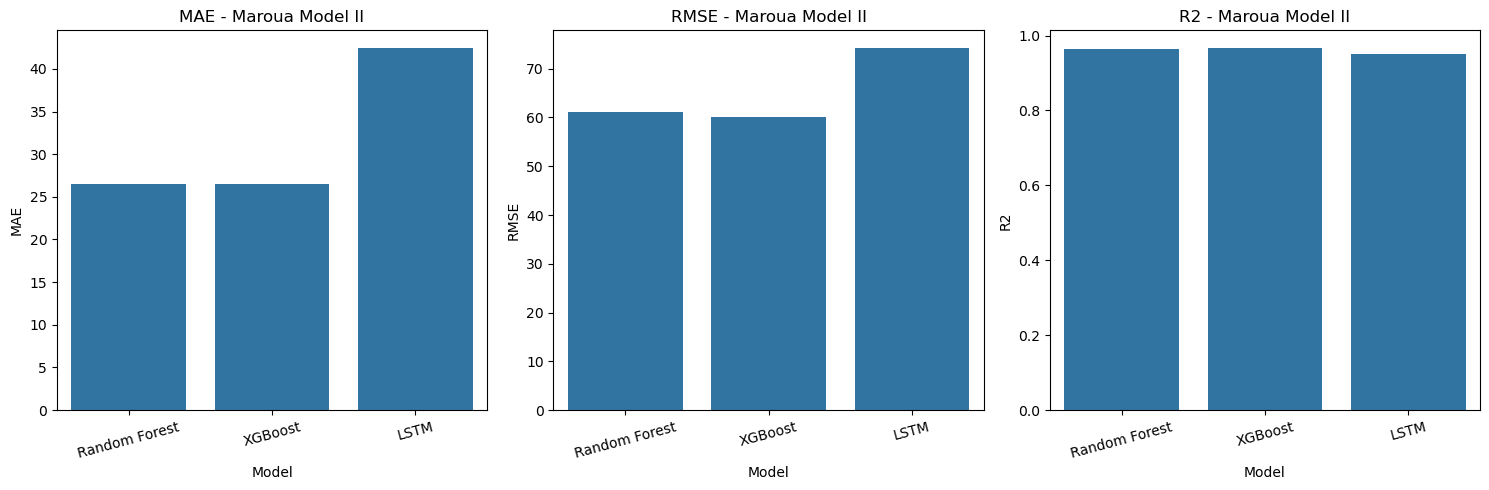

Best model for Maroua:
City        Maroua
Model      XGBoost
MAE      26.545543
RMSE     60.195426
R2        0.965669
Name: 1, dtype: object


In [13]:
metrics = ["MAE", "RMSE", "R2"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, metrics):
    sns.barplot(data=results, x="Model", y=metric, ax=ax)
    ax.set_title(f"{metric} - Maroua Model II")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

best_model = results.sort_values(by="R2", ascending=False).iloc[0]
print("Best model for Maroua:")
print(best_model)

## Save Models (.pkl)

In [14]:
rf_path = "saved_models/model_ii/maroua_rf_model_ii.pkl"
xgb_path = "saved_models/model_ii/maroua_xgb_model_ii.pkl"
lstm_path = "saved_models/model_ii/maroua_lstm_model_ii.pkl"

joblib.dump(rf, rf_path)
joblib.dump(xgb, xgb_path)
joblib.dump({
    "model": lstm_model,
    "scaler_X": scaler_X,
    "scaler_y": scaler_y,
    "seq_length": seq_length,
    "features": model_ii_features
}, lstm_path)

print("Saved:", rf_path)
print("Saved:", xgb_path)
print("Saved:", lstm_path)

Saved: saved_models/model_ii/maroua_rf_model_ii.pkl
Saved: saved_models/model_ii/maroua_xgb_model_ii.pkl
Saved: saved_models/model_ii/maroua_lstm_model_ii.pkl
